# Finished lab06

In [15]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from tqdm import tqdm


Try to move training to the GPU

In [2]:
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
os.makedirs("model", exist_ok=True)

## Loading datasets

In [4]:
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [5]:
data_dir = "./cats_dogs/cats_and_dogs_filtered/"  # Replace with your dataset path
datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ["train", "val"]
}

dataloaders = {
    x: DataLoader(datasets[x], batch_size=16, shuffle=True, num_workers=4)
    for x in ["train", "val"]
}

dataset_sizes = {x: len(datasets[x]) for x in ["train", "val"]}
class_names = datasets["train"].classes
print(f"Classes: {class_names}")

Classes: ['cats', 'dogs']


## Augmented data visualization

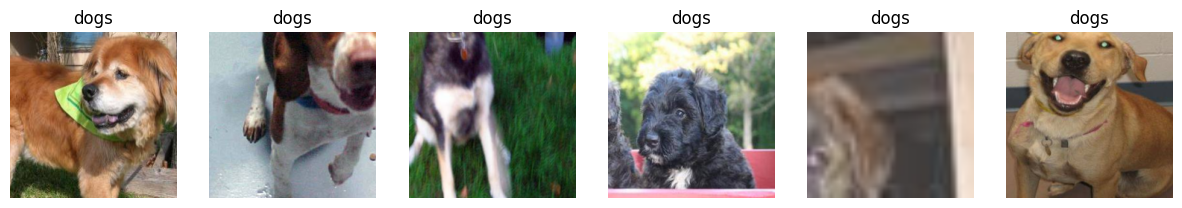

In [6]:
def visualize_augmented_data(dataloader, class_names, num_images=6):
    inputs, labels = next(iter(dataloader))
    inputs = inputs[:num_images]
    labels = labels[:num_images]
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, ax in enumerate(axes):
        img = inputs[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.show()

visualize_augmented_data(dataloaders["train"], class_names)

## Model definition

In [7]:
class MiniVGG(nn.Module):
    def __init__(self, num_classes):
        super(MiniVGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 56 * 56, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

## Training with Fine-Tuning


In [18]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, is_finetune=False):
    best_model_wts = model.state_dict()
    best_acc = 0.0

    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # Store accuracy for chart generation
            if phase == "train":
                train_accuracies.append(epoch_acc.item())
            else:
                val_accuracies.append(epoch_acc.item())

            # Save the best model
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    model.load_state_dict(best_model_wts)

    # Generate accuracy chart
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy", marker="o")
    plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model


## Transfer learning

In [ ]:
model = models.vgg16(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

num_classes = len(class_names)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)


### model training and saving best model

Epoch 1/10


100%|██████████| 125/125 [00:20<00:00,  6.02it/s]


train Loss: 0.1631 Acc: 0.9225


100%|██████████| 63/63 [00:08<00:00,  7.16it/s]


val Loss: 0.0331 Acc: 0.9860
Epoch 2/10


...

val Loss: 0.0229 Acc: 0.9910
Epoch 10/10


100%|██████████| 125/125 [00:21<00:00,  5.95it/s]


train Loss: 0.0741 Acc: 0.9705


100%|██████████| 63/63 [00:08<00:00,  7.05it/s]


val Loss: 0.0235 Acc: 0.9920


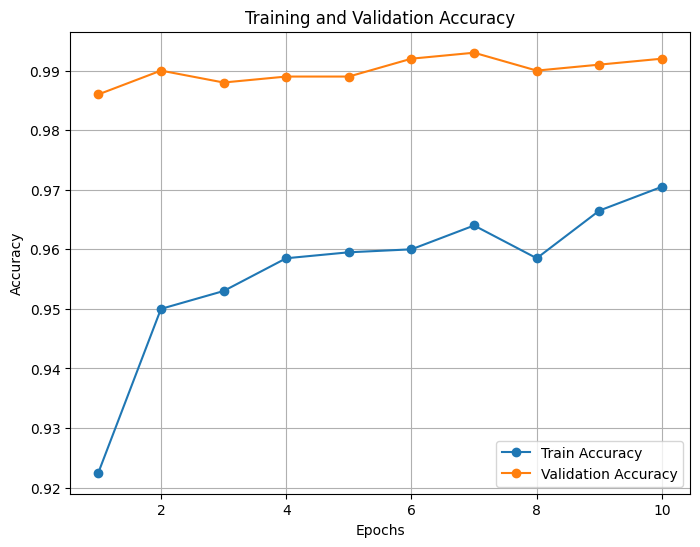

In [20]:
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=10)
torch.save(model.state_dict(), "model/transfer_learning_best.pth")


## Fine tuning

Epoch 1/10


100%|██████████| 125/125 [00:58<00:00,  2.15it/s]


train Loss: 0.0803 Acc: 0.9610


100%|██████████| 63/63 [00:08<00:00,  7.08it/s]


val Loss: 0.0230 Acc: 0.9920
Epoch 2/10


...

val Loss: 0.0201 Acc: 0.9910
Epoch 10/10


100%|██████████| 125/125 [00:58<00:00,  2.15it/s]


train Loss: 0.0725 Acc: 0.9675


100%|██████████| 63/63 [00:08<00:00,  7.08it/s]


val Loss: 0.0199 Acc: 0.9920


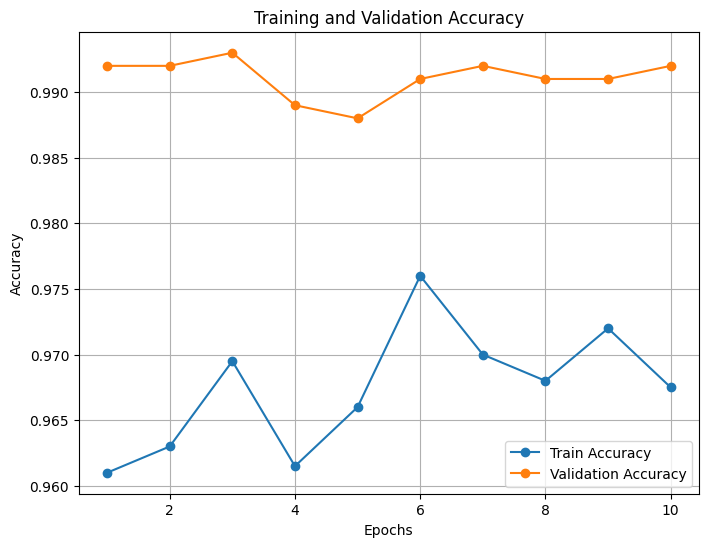

In [21]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=10, is_finetune=True)

torch.save(model.state_dict(), "model/fine_tuning_best.pth")

## Classyfying

In [22]:
def classify_image(image_path, model, class_names):
    model.eval()
    transform = data_transforms["val"]
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, preds = torch.max(outputs, 1)

    return class_names[preds[0]]

## Veryfying usage


In [25]:
model.load_state_dict(torch.load("model/transfer_learning_best.pth"))

image_path = "./manual_tests/ai-generated-cat-aria.png"
print(f"Predicted class: {classify_image(image_path, model, class_names)}")

image_path = "./manual_tests/ai-generated-dog-aria.png"
print(f"Predicted class: {classify_image(image_path, model, class_names)}")


/tmp/ipykernel_2332190/4029368505.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model/transfer_learning_best.pth"))


Predicted class: cats
Predicted class: dogs
